# 05 · Nested cross-validation and leakage prevention (protocol §5.3–5.6)

This notebook explains how performance is estimated honestly, and runs the primary analysis on the real data once they are ready.

## 1. Generalization and overfitting
- **The goal** is **generalization**: how well the classifier works on participants it has *never seen*.
- **Overfitting** means learning the training participants' noise instead of the pattern.
- **Why training performance tells you nothing here:** with $p \gg n$, a linear SVM separates any training set perfectly, even pure noise (Demo 1).
- **The consequence:** every performance number must come from participants who played **no part** in building the model.

## 2. Cross-validation (CV)
- **k-fold CV:** split the participants into $k$ folds. Train on $k-1$ folds and test on the remaining one, then rotate so every participant is tested exactly once.
- **Stratification:** each fold keeps the overall patient/control ratio. Without it, a small fold could end up with very few patients, and its AUC would be unstable or even undefined.

## 3. Data leakage
**Leakage** means information from the test participants influences the model before it is tested. The result is optimistically biased performance that will not replicate. Leakage is easy to introduce by accident, for example:

| Step | Leaky version | Correct version |
|---|---|---|
| Scaling | z-score using the mean/SD of all participants | fit the mean/SD on the training fold only |
| Feature selection | pick the "top-k" connections by correlation with diagnosis across all participants | refit the selection inside every training fold |
| Imputation | fill missing values using all participants | fit the imputer on the training fold (not needed here: no imputation) |
| **Kernel normalization** | scale by the trace of the full kernel | use the training-kernel trace for both train and test |
| Hyperparameters (C, β) | pick the values that look best on the test data | pick them by inner CV within the training fold |
| Decision threshold | choose the cut-off that looks best on the test fold | choose it from inner out-of-fold scores |
| Confound regression | fit confound slopes on all participants | fit them on the training fold (notebook 07) |

**The rule, applied without exception:** every data-dependent operation is **fit on training-fold data only** and **applied, not refit,** to the held-out fold.

Demo 2 shows how large the bias from leaky feature selection can be: pure noise comes out looking like AUC ≈ 0.9.

## 4. Nested cross-validation
Choosing C and β *is* learning from data. If you pick the configuration with the best CV score and then report that same score, the estimate is optimistic: with enough configurations, one of them looks good by chance (Demo 3). **Nested CV** separates the two jobs:

- **Outer loop:** repeated stratified 5-fold CV. For each outer fold, the entire pipeline is built on the outer-training participants and judged on the outer-test participants, *who were never touched by any tuning decision*. Only these outer-test predictions are reported.
- **Inner loop:** stratified 5-fold CV *inside each outer training fold*. It selects C, β and the threshold using the outer-training participants only.

The procedure, for each outer fold:
1. split the outer-training participants into 5 inner folds;
2. for each candidate (C, β): train on 4 inner folds, score the 5th, and rotate;
3. choose the (C, β) with the best mean inner AUC, and the threshold from those inner scores;
4. refit on *all* outer-training participants with the chosen (C, β);
5. score the outer-test participants **once**.

## 5. Repeated CV, seeds and pairing
- **Repeats.** A single 5-fold split is one random partition, and the result depends on which participants happened to land together. Repeating the outer CV 10 times with different seeds gives a *distribution* of performance across partitions.
  - The repeats reuse the same participants, so they are **not independent replications** and are never treated as independent studies. This is also why a naive standard error is wrong (notebook 06).
- **Seeds.** Random number generators are initialized from the 10 fixed seeds in `configs/seeds.txt`. Each inner split's seed is derived from its outer seed and fold number, so the whole analysis is exactly reproducible.
- **Pairing.** *Every model sees identical outer and inner splits*. The MKL and functional predictions for a participant therefore come from the same partition, and their difference can be analysed **paired**.

## 6. The decision threshold
An SVM outputs a continuous **decision score**. Turning that score into a yes/no classification needs a **threshold**, and the score does not come with a clinically meaningful threshold of its own. The protocol had three candidates:

| Option | Idea |
|---|---|
| Threshold = 0 | the SVM's own boundary |
| **Youden's J, chosen inside the inner CV (selected)** | the threshold that best balances sensitivity and specificity |
| Sensitivity-oriented | e.g. the threshold that achieves ≥ 90% sensitivity |

**Youden's J statistic:** $J = \text{sensitivity} + \text{specificity} - 1$. It is the vertical distance between the ROC curve and the chance diagonal.

How the threshold is chosen:
1. pool the inner out-of-fold scores of the selected configuration;
2. take the threshold $t$ that maximizes $J$; if several tie, take the one closest to 0;
3. classify outer-test participants with score ≥ $t$ as patients.

The threshold is **never** chosen using outer-test participants.

**Caveat.** The inner models are trained on about 80% of the outer training fold, so their score scale can differ slightly from that of the refit model.

**Sensitivity analysis.** Threshold-based metrics are also reported at threshold 0 (notebook 06).

In [1]:
from pathlib import Path
from functools import partial
from importlib import metadata
import hashlib
import json
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedKFold

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"
RESULTS = ROOT / "results"


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
use_notebook("04_kernels_and_models.ipynb")   # kernels, KernelSVM, Stacking, build_models, make_synthetic

In [3]:
def read_seeds(path):
    lines = (line.strip() for line in Path(path).read_text(encoding="utf-8").splitlines())
    return [int(line) for line in lines if line and not line.startswith("#")]


def outer_splits(y, n_splits, seeds):
    """(repeat, seed, fold, train_idx, test_idx) for every repeat; shared by all models."""
    splits = []
    for repeat, seed in enumerate(seeds):
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        for fold, (train, test) in enumerate(cv.split(np.zeros(len(y)), y)):
            splits.append((repeat, seed, fold, train, test))
    return splits


def inner_splits(y_train, n_splits, seed, fold):
    """Stratified splits of one outer training fold (indices relative to that fold)."""
    inner_seed = int(np.random.SeedSequence([seed, fold]).generate_state(1)[0])
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=inner_seed)
    return list(cv.split(np.zeros(len(y_train)), y_train))


def run_outer_fold(X, y, ids, split, models, n_inner, collect_weights=False):
    """Fit every model on one outer training fold and score its outer test fold."""
    repeat, seed, fold, train, test = split
    inner = inner_splits(y[train], n_inner, seed, fold)
    predictions, selections, weights = [], [], {}
    for model in models:
        model.fit(X[train], y[train], inner)
        score = model.decision_function(X[test])
        predictions.append(pd.DataFrame({
            "model": model.name, "repeat": repeat, "seed": seed, "fold": fold,
            "participant_id": ids[test], "y_true": y[test], "score": score,
            "threshold": model.threshold_, "y_pred": (score >= model.threshold_).astype(int),
        }))
        selections.append({"model": model.name, "repeat": repeat, "fold": fold,
                           "n_train": len(train), "n_test": len(test), **model.selection()})
        if collect_weights and hasattr(model, "primal_weights"):
            for modality, w in model.primal_weights().items():
                weights[f"{model.name}__r{repeat}__f{fold}__{modality}"] = w
    return pd.concat(predictions, ignore_index=True), selections, weights


def run_nested_cv(X, y, ids, model_factory, seeds, n_outer=5, n_inner=5, n_jobs=1, collect_weights=False):
    """Repeated nested CV of every model from ``model_factory()`` (called fresh per outer fold)."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int)
    ids = np.asarray(ids)
    results = Parallel(n_jobs=n_jobs)(
        delayed(run_outer_fold)(X, y, ids, split, model_factory(), n_inner, collect_weights)
        for split in outer_splits(y, n_outer, seeds))
    predictions = pd.concat([r[0] for r in results], ignore_index=True)
    selections = pd.DataFrame([row for r in results for row in r[1]])
    weights = {key: w for r in results for key, w in r[2].items()}
    return predictions, selections, weights


def demo_config(C_grid=(0.1, 1.0), beta_grid=(0.0, 0.5, 1.0)):
    """The locked model config with smaller grids -- for fast demonstrations only."""
    cfg = load_yaml(ROOT / "configs" / "model_config.yaml")
    cfg["svm"]["C_grid"] = list(C_grid)
    cfg["mkl"]["beta_grid"] = list(beta_grid)
    return cfg

In [4]:
def load_design(data_config, functional_strategy="primary", strict_patients=False):
    """Design matrix with column blocks structural | functional | confounds (no imputation)."""
    features = ROOT / data_config["features_dir"]
    manifest = pd.read_csv(ROOT / data_config["manifest"], dtype={"participant_id": str})
    manifest = manifest[manifest["included"] == 1]
    if strict_patients:
        manifest = manifest[(manifest["label"] == 0) | (manifest["strict_patient"] == 1)]
    structural = pd.read_csv(features / "structural_features.csv", dtype={"participant_id": str})
    functional = pd.read_csv(features / f"functional_features_{functional_strategy}.csv", dtype={"participant_id": str})
    tables = [structural, functional,
              pd.read_csv(features / "structural_qc.csv", dtype={"participant_id": str}),
              pd.read_csv(features / "functional_qc_primary.csv", dtype={"participant_id": str})]
    design = manifest
    for table in tables:
        design = design.merge(table, on="participant_id", how="left", validate="one_to_one")

    columns = {"structural": [c for c in structural.columns if c != "participant_id"],
               "functional": [c for c in functional.columns if c != "participant_id"],
               "confounds": list(data_config["confound_columns"])}
    X = design[columns["structural"] + columns["functional"] + columns["confounds"]].to_numpy(dtype=float)
    if np.isnan(X).any():
        bad = design.loc[np.isnan(X).any(axis=1), "participant_id"].tolist()
        raise ValueError(f"Missing values for included participants (no imputation allowed): {bad}")
    blocks, start = {}, 0
    for name in ("structural", "functional", "confounds"):
        blocks[name] = np.arange(start, start + len(columns[name]))
        start += len(columns[name])
    return X, design["label"].to_numpy(int), design["participant_id"].to_numpy(), blocks, columns


def file_sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def run_primary_analysis(models=None, functional_strategy="primary", strict_patients=False, tag="", n_jobs=-1):
    """Repeated nested CV of the configured models on the real data; writes results/."""
    model_cfg = load_yaml(ROOT / "configs" / "model_config.yaml")
    cv_cfg = load_yaml(ROOT / "configs" / "cv_config.yaml")
    data_cfg = load_yaml(ROOT / "configs" / "data_config.yaml")
    seeds = read_seeds(ROOT / cv_cfg["seeds_file"])
    if len(seeds) != cv_cfg["outer"]["n_repeats"]:
        raise ValueError("Number of seeds does not match outer.n_repeats.")
    X, y, ids, blocks, columns = load_design(data_cfg, functional_strategy, strict_patients)
    names = models or [m["name"] for m in model_cfg["models"]]
    start = time.perf_counter()
    predictions, selections, weights = run_nested_cv(
        X, y, ids, partial(build_models, model_cfg, blocks, include=names), seeds,
        cv_cfg["outer"]["n_splits"], cv_cfg["inner"]["n_splits"], n_jobs=n_jobs, collect_weights=True)

    suffix = f"_{tag}" if tag else ""
    (RESULTS / "predictions").mkdir(parents=True, exist_ok=True)
    (RESULTS / "metrics").mkdir(parents=True, exist_ok=True)
    predictions.to_csv(RESULTS / "predictions" / f"predictions{suffix}.csv", index=False)
    selections.to_csv(RESULTS / "metrics" / f"selections{suffix}.csv", index=False)
    np.savez_compressed(RESULTS / "predictions" / f"primal_weights{suffix}.npz", **weights)
    hashed = [*sorted((ROOT / "configs").glob("*.yaml")), ROOT / cv_cfg["seeds_file"], ROOT / "protocol" / "protocol.md"]
    packages = {}
    for package in ("numpy", "scipy", "pandas", "scikit-learn", "nilearn", "nibabel", "joblib"):
        try:
            packages[package] = metadata.version(package)
        except metadata.PackageNotFoundError:
            packages[package] = None
    run_info = {
        "models": names, "tag": tag, "functional_strategy": functional_strategy, "strict_patients": strict_patients,
        "n_participants": int(len(y)), "n_patients": int(y.sum()), "n_controls": int((y == 0).sum()),
        "n_features": {name: len(cols) for name, cols in columns.items()}, "seeds": seeds,
        "elapsed_seconds": round(time.perf_counter() - start, 1),
        "sha256": {p.name: file_sha256(p) for p in hashed},
        "packages": packages, "python": platform.python_version(), "platform": platform.platform(),
    }
    (RESULTS / "metrics" / f"run_info{suffix}.json").write_text(json.dumps(run_info, indent=2))
    return predictions, selections, weights

## Demo 1: with p ≫ n, training performance is meaningless
- **Data:** 60 participants, 2,000 pure-noise features, random labels.
- **Result:** the SVM is perfect on its own training participants and at chance on new ones.

In [5]:
from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC

rng = np.random.default_rng(0)
X_noise = rng.normal(size=(60, 2000))
y_noise = np.array([0, 1] * 30)
svm = SVC(kernel="linear", C=1.0).fit(X_noise[:40], y_noise[:40])
print(f"training AUC: {roc_auc_score(y_noise[:40], svm.decision_function(X_noise[:40])):.2f}")
print(f"test AUC:     {roc_auc_score(y_noise[40:], svm.decision_function(X_noise[40:])):.2f}")

training AUC: 1.00
test AUC:     0.38


## Demo 2: leakage through feature selection
- **Data:** pure noise again, 10 independent datasets.
- **Leaky:** select the 20 features most associated with the labels using *all* participants, then cross-validate.
- **Correct:** refit the same selection inside every training fold.

In [6]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

leaky, correct = [], []
for dataset in range(10):
    X_noise = rng.normal(size=(60, 2000))
    cv = StratifiedKFold(5, shuffle=True, random_state=dataset)
    top = SelectKBest(f_classif, k=20).fit(X_noise, y_noise).get_support()          # uses ALL participants
    leaky.append(cross_val_score(SVC(kernel="linear"), X_noise[:, top], y_noise, cv=cv, scoring="roc_auc").mean())
    pipeline = make_pipeline(SelectKBest(f_classif, k=20), SVC(kernel="linear"))    # refit inside each fold
    correct.append(cross_val_score(pipeline, X_noise, y_noise, cv=cv, scoring="roc_auc").mean())
print("Pure noise: the true AUC is 0.5")
print(f"  feature selection outside CV (leaky): mean AUC = {np.mean(leaky):.2f}")
print(f"  feature selection inside CV (correct): mean AUC = {np.mean(correct):.2f}")

Pure noise: the true AUC is 0.5
  feature selection outside CV (leaky): mean AUC = 0.95
  feature selection inside CV (correct): mean AUC = 0.49


## Demo 3: why tuning needs its own inner loop
- **Data:** noise again.
- **Non-nested:** search a grid of 20 configurations (number of features × C) and report the best cross-validated score. This number is **optimistic**, because the "best" configuration was picked *using* those same scores.
- **Nested:** the same search wrapped in an outer CV. This gives an honest estimate close to 0.5.

In [7]:
from sklearn.model_selection import GridSearchCV

grid = {"selectkbest__k": [5, 10, 20, 50, 100], "svc__C": [0.01, 0.1, 1, 10]}
best_of_grid, nested = [], []
for dataset in range(5):
    X_noise = rng.normal(size=(60, 500))
    search = GridSearchCV(make_pipeline(SelectKBest(f_classif), SVC(kernel="linear")), grid,
                          cv=StratifiedKFold(5, shuffle=True, random_state=dataset), scoring="roc_auc")
    best_of_grid.append(search.fit(X_noise, y_noise).best_score_)
    nested.append(cross_val_score(search, X_noise, y_noise, scoring="roc_auc",
                                  cv=StratifiedKFold(5, shuffle=True, random_state=100 + dataset)).mean())
print(f"best-of-grid CV AUC (non-nested, optimistic): {np.mean(best_of_grid):.2f}")
print(f"nested CV AUC (honest):                       {np.mean(nested):.2f}")

best-of-grid CV AUC (non-nested, optimistic): 0.59
nested CV AUC (honest):                       0.52


## Demo 4: repeated stratified splits
Each row is one repeat and each column one participant, and the colour shows which outer fold tests that participant. Every participant is tested exactly once per repeat, and every test fold keeps the 30:20 control/patient ratio.

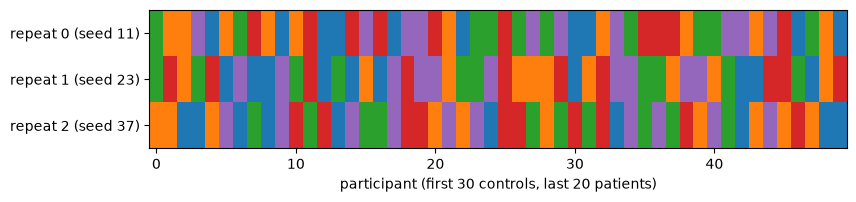

patients per test fold in repeat 0: [4, 4, 4, 4, 4]


In [8]:
y_demo = np.array([0] * 30 + [1] * 20)
splits = outer_splits(y_demo, 5, seeds=[11, 23, 37])
fold_of = np.zeros((3, len(y_demo)), dtype=int)
for repeat, seed, fold, train, test in splits:
    fold_of[repeat, test] = fold
fig, ax = plt.subplots(figsize=(9, 1.8))
ax.imshow(fold_of, aspect="auto", cmap="tab10", vmin=0, vmax=9, interpolation="nearest")
ax.set_yticks(range(3), [f"repeat {r} (seed {s})" for r, s in enumerate([11, 23, 37])])
ax.set_xlabel("participant (first 30 controls, last 20 patients)")
plt.show()
print("patients per test fold in repeat 0:", [int(y_demo[s[4]].sum()) for s in splits if s[0] == 0])

## Demo 5: Youden's J picks the threshold
On the ROC curve, $J$ is the vertical distance from the diagonal. The marked point is the threshold that `youden_threshold` selects.

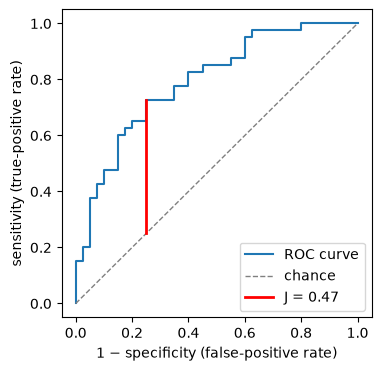

selected threshold = 0.651


In [9]:
y_scores = np.r_[np.zeros(40), np.ones(40)].astype(int)
scores = np.r_[rng.normal(0, 1, 40), rng.normal(1.2, 1, 40)]
threshold = youden_threshold(y_scores, scores)
fpr, tpr, thresholds = roc_curve(y_scores, scores, drop_intermediate=False)
i = np.argmin(np.abs(thresholds - threshold))
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(fpr, tpr, label="ROC curve")
ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1, label="chance")
ax.plot([fpr[i], fpr[i]], [fpr[i], tpr[i]], color="red", lw=2, label=f"J = {tpr[i] - fpr[i]:.2f}")
ax.set_xlabel("1 − specificity (false-positive rate)")
ax.set_ylabel("sensitivity (true-positive rate)")
ax.legend(loc="lower right")
plt.show()
print(f"selected threshold = {threshold:.3f}")

## Demo 6: the full nested pipeline on synthetic data
This runs every model in the locked config with smaller grids, for speed.
- **Outputs:** one row per participant × model × repeat (the predictions), and one row per model × fold (the selections: chosen C, β, threshold and inner AUC).
- **Parallelism:** `n_jobs` sets how many outer folds are fitted at the same time.

In [10]:
X, y, blocks = make_synthetic(n=60, signal="both", effect=1.0)
ids = np.array([f"sub-{i:02d}" for i in range(len(y))])
predictions, selections, weights = run_nested_cv(
    X, y, ids, partial(build_models, demo_config(), blocks), seeds=[11, 23],
    n_outer=5, n_inner=3, n_jobs=2, collect_weights=True)
print(f"{len(predictions)} prediction rows = {predictions['model'].nunique()} models × {len(y)} participants × 2 repeats")
display(predictions.head())
display(selections[["model", "repeat", "fold", "C", "beta_structural", "threshold", "inner_auc"]].head(10))

1200 prediction rows = 10 models × 60 participants × 2 repeats


,model,repeat,seed,fold,participant_id,y_true,score,threshold,y_pred
0,structural,0,11,0,sub-05,0,-0.741429,0.12045,0
1,structural,0,11,0,sub-06,1,0.392334,0.12045,1
2,structural,0,11,0,sub-12,0,-0.403315,0.12045,0
3,structural,0,11,0,sub-13,1,-0.022900,0.12045,0
4,structural,0,11,0,sub-17,1,0.010545,0.12045,0


,model,repeat,fold,C,beta_structural,threshold,inner_auc
0,structural,0,0,0.1,1.000000,0.120450,0.901042
1,functional,0,0,0.1,NaN,-0.018533,0.921875
2,early_fusion,0,0,1.0,0.142857,0.073274,0.989583
3,equal_weight,0,0,1.0,0.500000,-0.173212,0.994792
4,mkl,0,0,1.0,0.500000,-0.173212,0.994792
5,stacking,0,0,NaN,NaN,0.844597,0.984375
6,confounds_only,0,0,1.0,NaN,0.247265,0.541667
7,mkl_alignment,0,0,1.0,0.500282,-0.045965,0.989583
8,functional_residualized,0,0,1.0,NaN,0.026800,0.906250
9,mkl_residualized,0,0,1.0,0.500000,0.087476,0.932292


## Demo 7: a leakage check you can run
- **The change:** we alter the features *and labels* of every outer-test participant except the first, then refit the fold.
- **Why the first participant's score should not move:** in a leak-free pipeline, a test participant's prediction depends only on the training data and on that participant's own features.

In [11]:
split = outer_splits(y, 4, [0])[0]
test = split[4]
names = ["mkl", "stacking", "mkl_residualized"]
before, _, _ = run_outer_fold(X, y, ids, split, build_models(demo_config(), blocks, names), 3)
X_changed, y_changed = X.copy(), y.copy()
X_changed[test[1:]] = rng.normal(size=(len(test) - 1, X.shape[1])) * 10
y_changed[test] = 1 - y_changed[test]
after, _, _ = run_outer_fold(X_changed, y_changed, ids, split, build_models(demo_config(), blocks, names), 3)
first = ids[test[0]]
for name in names:
    a = before.query("model == @name and participant_id == @first")["score"].item()
    b = after.query("model == @name and participant_id == @first")["score"].item()
    print(f"{name:18s} score before {a:+.6f}  after {b:+.6f}  unchanged: {np.isclose(a, b)}")

mkl                score before -0.536817  after -0.536817  unchanged: True
stacking           score before -1.606637  after -1.606637  unchanged: True
mkl_residualized   score before -0.565574  after -0.565574  unchanged: True


## Run the primary analysis on the real data
Before running this cell:
- the manifest (notebook 01) and the features (notebooks 02–03) must exist;
- **the protocol must be locked** (protocol §14).

What it does:
- runs all models with the full grids, 10 repeats × 5 outer folds × 5 inner folds;
- takes about 80 s of single-core compute at COBRE size;
- writes the predictions, selections, weights and `run_info.json` (versions and hashes) to `results/`.

Sensitivity runs reuse the function, e.g. `run_primary_analysis(functional_strategy="simple", tag="simple")` or `run_primary_analysis(models=["mkl", "functional"], strict_patients=True, tag="strict")`.

In [12]:
USE_REAL_DATA = False

if USE_REAL_DATA:
    predictions, selections, weights = run_primary_analysis(n_jobs=-1)
    display(selections.groupby("model")[["inner_auc"]].mean())
else:
    print("Synthetic mode: set USE_REAL_DATA = True after the protocol is locked and features exist.")

Synthetic mode: set USE_REAL_DATA = True after the protocol is locked and features exist.
